# Image Likelihood Explorer

Goal: understand what the Poisson image log-likelihood looks like as a function
of **all 8 cloud nuisance parameters in initial-condition space**
for N=1 and N>1 shots.

Parameters: `[mu_x0, mu_y0, mu_vx0, mu_vy0, sigma_x0, sigma_y0, sigma_vx0, sigma_vy0]`

No reparameterization — we keep the native initial-condition coordinates and let the
PSMAP structure (if any) break the apparent mu_x0/mu_vx0 degeneracy.

**Likelihood per shot:**
$$
\log L_i(\theta) = \log \frac{1}{K} \sum_{k=1}^{K}
  \exp\Bigl[
    \sum_{z\in\{Z0,Z100\}} \sum_{s,b} \bigl(
      n_{izsb}\,\log \lambda_{izsb}(\phi_k) - \lambda_{izsb}(\phi_k)
    \bigr)
  \Bigr]
$$
where $\phi_k$ are K equally spaced phases in $[0,2\pi)$.

**Multi-shot:** $\log L(\theta) = \sum_i \log L_i(\theta)$.

In [17]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

REPO = os.path.abspath('..')
sys.path.insert(0, os.path.join(REPO, 'helpers'))
sys.path.insert(0, '/home/ndm33/local/aispy')

from helpers import ImageShotDataset
from psmap_fisher import PSMAPConditionalImageModel
from aispy.psmap import load_psmap

try:
    import cupy as cp
    from cupyx.scipy.special import logsumexp as cp_logsumexp
    xp = cp
    print('CuPy available — GPU enabled')
except ImportError:
    cp = None
    from scipy.special import logsumexp as np_logsumexp
    xp = np
    print('CuPy not found — CPU only')

def lse(a, axis=None):
    if xp is cp:
        return cp_logsumexp(a, axis=axis)
    return np_logsumexp(a, axis=axis)

CuPy available — GPU enabled


In [18]:
RUN   = ('R20_N200_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx100um_'
         'sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000')
DATA_ROOT  = os.path.join(REPO, 'data', RUN, 'run_000')
PSMAP_ROOT = os.path.join(REPO, 'output-files')

T_DET    = 3.8    # detection time [s]
BINS     = 8     # downsample resolution
HERMITE  = 5      # Gauss-Hermite quadrature order
N_THETA  = 64    # phi integration points

ds_z0   = ImageShotDataset(os.path.join(DATA_ROOT, 'Z0',   'data_IMG.h5'))
ds_z100 = ImageShotDataset(os.path.join(DATA_ROOT, 'Z100', 'data_IMG.h5'))
print(f'{ds_z0.n_shots} shots,  {ds_z0.res}×{ds_z0.res} px,  half_range={ds_z0.half_range*1e3:.1f} mm')

edges   = np.linspace(-ds_z0.half_range, ds_z0.half_range, BINS + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

print('Loading PSMAPs...', end=' ', flush=True)
psmap_z0   = load_psmap(os.path.join(PSMAP_ROOT, 'PSGRID4D_CONFOCAL_Z0.h5'))
psmap_z100 = load_psmap(os.path.join(PSMAP_ROOT, 'PSGRID4D_CONFOCAL_Z100.h5'))
print('done')

200 shots,  2048×2048 px,  half_range=3.0 mm
Loading PSMAPs... 

KeyboardInterrupt: 

In [ ]:
PHASE_POINTS = [0.0, np.pi / 2, np.pi]

def build_models(psmap):
    return [PSMAPConditionalImageModel.from_psmap(
                psmap, T_DET, phi0, edges, edges, hermite_order=HERMITE)
            for phi0 in PHASE_POINTS]

t0 = time.perf_counter()
print('Building 6 conditional image models...', end=' ', flush=True)
models_z0   = build_models(psmap_z0)
models_z100 = build_models(psmap_z100)
print(f'done  ({time.perf_counter()-t0:.1f}s)')

Building 6 conditional image models... done  (0.3s)


In [ ]:
def downsample(img):
    b = ds_z0.res // BINS
    img = np.asarray(img, dtype=np.float64)
    if img.ndim == 2:
        return img.reshape(BINS, b, BINS, b).sum(axis=(1, 3))
    return img.reshape(2, BINS, b, BINS, b).sum(axis=(2, 4))

def extract_acs(models, theta):
    """3-point phi extraction → (A, Cc, Cs) each shape (2*n_pix,)."""
    p0   = models[0].detected_probabilities(theta)
    p90  = models[1].detected_probabilities(theta)
    p180 = models[2].detected_probabilities(theta)
    A  = 0.5 * (p0 + p180)
    Cc = 0.5 * (p0 - p180)
    Cs = p90 - A
    return A, Cc, Cs

def phi_marginal_logL(n0, n1, A0, Cc0, Cs0, A1, Cc1, Cs1,
                      n_theta=N_THETA, delta_phi=0.0):
    """Marginalise phi_i on GPU; n0/n1 are 1-D count arrays (2*n_pix,)."""
    L0 = float(n0.sum()) / max(float(A0.sum()), 1e-300)
    L1 = float(n1.sum()) / max(float(A1.sum()), 1e-300)

    A0g  = xp.asarray(A0);  Cc0g = xp.asarray(Cc0); Cs0g = xp.asarray(Cs0)
    A1g  = xp.asarray(A1);  Cc1g = xp.asarray(Cc1); Cs1g = xp.asarray(Cs1)
    n0g  = xp.asarray(n0.astype(np.float64))
    n1g  = xp.asarray(n1.astype(np.float64))

    phi  = xp.linspace(0, 2*np.pi, n_theta, endpoint=False)
    c    = xp.cos(phi); s = xp.sin(phi)

    lam0 = L0  * (A0g[None] + Cc0g[None]*c[:,None] + Cs0g[None]*s[:,None])
    lam0 = xp.maximum(lam0, 1e-300)
    ll0  = (n0g[None] * xp.log(lam0) - lam0).sum(axis=1)

    phi1  = phi + float(delta_phi)
    c1 = xp.cos(phi1); s1 = xp.sin(phi1)
    lam1 = L1  * (A1g[None] + Cc1g[None]*c1[:,None] + Cs1g[None]*s1[:,None])
    lam1 = xp.maximum(lam1, 1e-300)
    ll1  = (n1g[None] * xp.log(lam1) - lam1).sum(axis=1)

    return float(lse(ll0 + ll1) - np.log(n_theta))

def shot_logL(i_shot, theta, n_theta=N_THETA, delta_phi=0.0):
    """
    Marginal log-likelihood for shot i_shot.
    theta = [mu_x0, mu_y0, mu_vx0, mu_vy0, sigma_x0, sigma_y0, sigma_vx0, sigma_vy0]
    """
    theta = np.asarray(theta, dtype=float)
    n0 = downsample(ds_z0[i_shot]).reshape(2, -1).ravel()
    n1 = downsample(ds_z100[i_shot]).reshape(2, -1).ravel()
    A0, Cc0, Cs0 = extract_acs(models_z0,   theta)
    A1, Cc1, Cs1 = extract_acs(models_z100, theta)
    return phi_marginal_logL(n0, n1, A0, Cc0, Cs0, A1, Cc1, Cs1,
                             n_theta=n_theta, delta_phi=delta_phi)

def multi_shot_logL(shot_indices, theta, n_theta=N_THETA):
    return sum(shot_logL(i, theta, n_theta=n_theta) for i in shot_indices)

In [ ]:
# ── True parameters for a single shot, in initial-condition space ─────────────
SHOT = 0
m    = ds_z0.meta(SHOT)

theta_true = np.array([
    m['mu_x0'],  m['mu_y0'],
    m['mu_vx0'], m['mu_vy0'],
    m['sigma_x'], m['sigma_y'],
    m['sigma_vx'], m['sigma_vy'],
])

PARAM_NAMES  = ['mu_x0', 'mu_y0', 'mu_vx0', 'mu_vy0',
                'sigma_x0', 'sigma_y0', 'sigma_vx0', 'sigma_vy0']
PARAM_UNITS  = ['µm',  'µm',  'µm/s', 'µm/s', 'µm', 'µm', 'µm/s', 'µm/s']
PARAM_SCALES = [1e-6,  1e-6,  1e-6,   1e-6,   1e-6, 1e-6, 1e-6,   1e-6  ]

print(f'True theta for shot {SHOT}:')
for name, unit, scale, val in zip(PARAM_NAMES, PARAM_UNITS, PARAM_SCALES, theta_true):
    print(f'  {name:12s} = {val/scale:+8.2f} {unit}')
print(f'  (mu_xf = mu_x0 + T*mu_vx0 = {(theta_true[0]+T_DET*theta_true[2])*1e6:+.2f} µm)')

print('\nEvaluating logL at true theta...', end=' ', flush=True)
t0 = time.perf_counter()
logL_true = shot_logL(SHOT, theta_true)
print(f'done ({time.perf_counter()-t0:.1f}s)  logL = {logL_true:.2f}')

True theta for shot 0:
  mu_x0        =    +6.15 µm
  mu_y0        =   -15.20 µm
  mu_vx0       =    +2.26 µm/s
  mu_vy0       =    -9.32 µm/s
  sigma_x0     =  +100.31 µm
  sigma_y0     =   +89.58 µm
  sigma_vx0    =   +97.05 µm/s
  sigma_vy0    =  +103.74 µm/s
  (mu_xf = mu_x0 + T*mu_vx0 = +14.72 µm)

Evaluating logL at true theta... done (0.1s)  logL = 17071061.74


## 1D likelihood profiles — all 8 parameters, single shot

Each panel sweeps one parameter while holding all others at their true values.
$\Delta\log L < 0$ means the truth is preferred; a flat profile means no information.

In [ ]:
# ── sweep ranges (half-width around true value) ───────────────────────────────
# mu_x0 / mu_vx0: wide enough to cover the degeneracy ridge
# The ridge is mu_x0 + T_det*mu_vx0 = const, so sweeping mu_x0 by ±Δx is
# equivalent to sweeping mu_vx0 by ±Δx/T_det.  Use commensurate ranges.
HALF_RANGES = [
    500e-6,   # mu_x0   [m]     ±500 µm
    500e-6,   # mu_y0   [m]
    150e-6,   # mu_vx0  [m/s]   ±150 µm/s  (500µm / 3.8s ≈ 132 µm/s)
    150e-6,   # mu_vy0  [m/s]
    200e-6,   # sigma_x0 [m]    ±80 µm
    200e-6,   # sigma_y0 [m]
    200e-6,   # sigma_vx0 [m/s] ±200 µm/s
    200e-6,   # sigma_vy0 [m/s]
]

N_PTS_1D = 31
results_1d = {}

print('1D sweeps (all 8 params, shot 0):')
for idx, (name, unit, scale, half_rng) in enumerate(
        zip(PARAM_NAMES, PARAM_UNITS, PARAM_SCALES, HALF_RANGES)):
    true_val = theta_true[idx]
    vals = np.linspace(true_val - half_rng, true_val + half_rng, N_PTS_1D)
    lls  = []
    print(f'  {name:12s}...', end='', flush=True)
    t0 = time.perf_counter()
    for v in vals:
        th = theta_true.copy()
        th[idx] = v
        if any(th[k] <= 0 for k in [4, 5, 6, 7]):
            lls.append(-np.inf)
        else:
            lls.append(shot_logL(SHOT, th))
    lls = np.array(lls)
    peak = np.nanmax(lls) - logL_true
    print(f' {time.perf_counter()-t0:.0f}s  peak_delta={peak:+.1f}')
    results_1d[name] = (vals, lls)

print('Done.')

1D sweeps (all 8 params, shot 0):
  mu_x0       ... 3s  peak_delta=+10397.4
  mu_y0       ... 4s  peak_delta=+8801.9
  mu_vx0      ... 3s  peak_delta=+10483.5
  mu_vy0      ... 3s  peak_delta=+8885.3
  sigma_x0    ... 2s  peak_delta=+22509.2
  sigma_y0    ... 2s  peak_delta=+26168.5
  sigma_vx0   ... 2s  peak_delta=+23364.4
  sigma_vy0   ... 2s  peak_delta=+29011.4
Done.


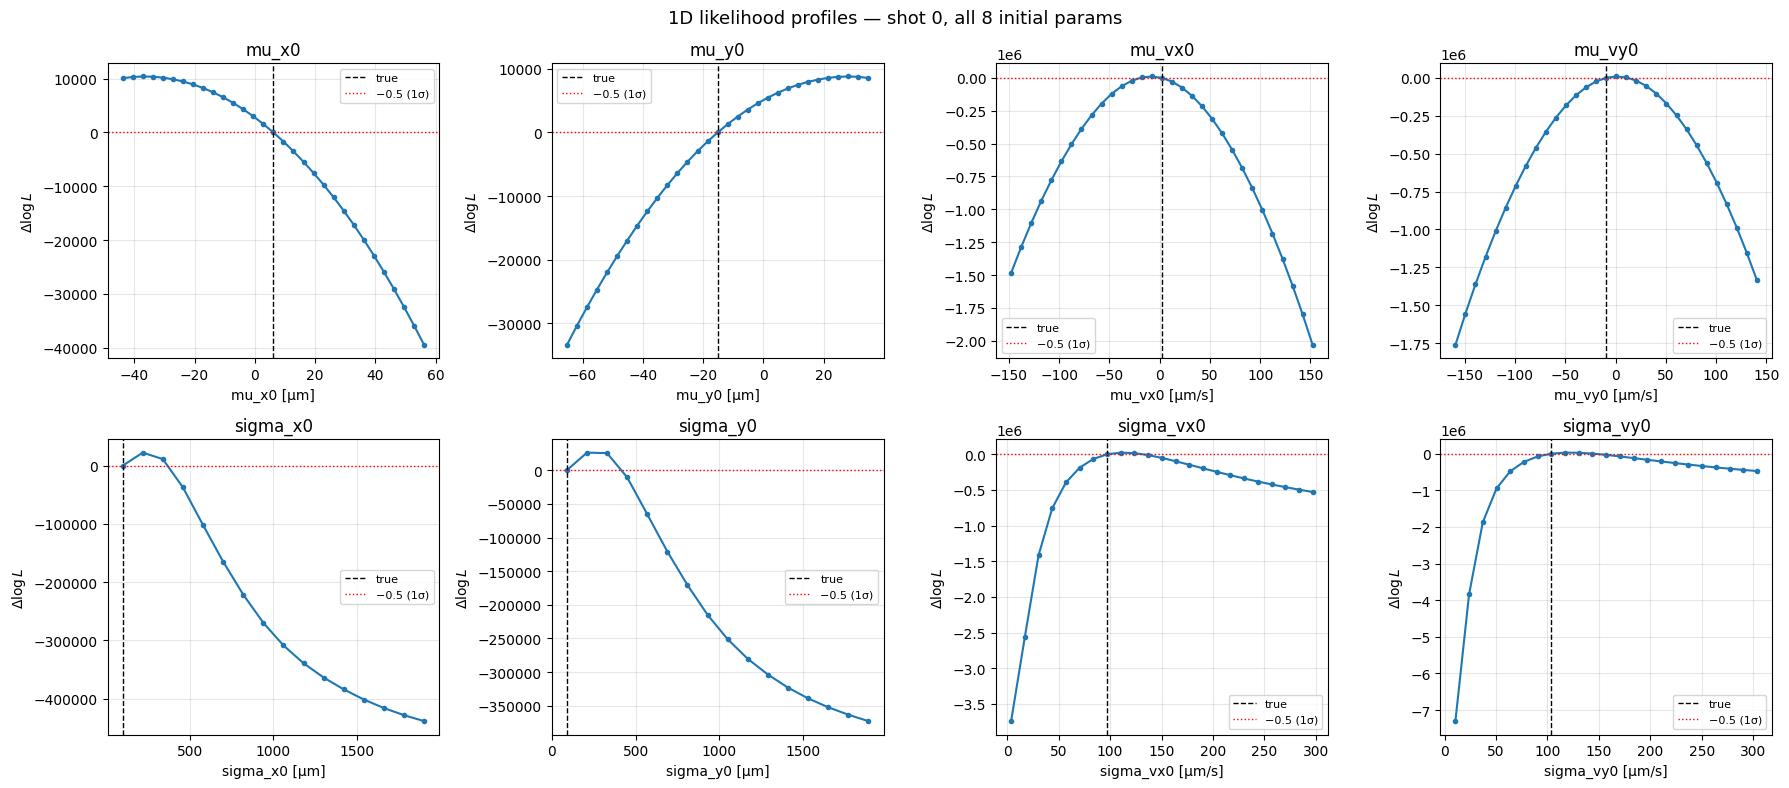

Saved results/ll_1d_all_params.pdf


In [20]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for idx, (name, unit, scale, ax) in enumerate(
        zip(PARAM_NAMES, PARAM_UNITS, PARAM_SCALES, axes)):
    vals, lls = results_1d[name]
    delta = lls - logL_true
    ax.plot(vals / scale, delta, 'C0-o', ms=3, lw=1.5)
    ax.axvline(theta_true[idx] / scale, color='k', ls='--', lw=1, label='true')
    ax.axhline(-0.5, color='r', ls=':', lw=1, label='−0.5 (1σ)')
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel(r'$\Delta\log L$')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle(f'1D likelihood profiles — shot {SHOT}, all 8 initial params', fontsize=13)
fig.tight_layout()
plt.savefig('../results/ll_1d_all_params.pdf', bbox_inches='tight')
plt.show()
print('Saved results/ll_1d_all_params.pdf')

## 2D slice likelihood — corner plot, single shot

Key pairs:
- **(mu_x0, mu_vx0)**: if the likelihood is flat along the ridge
  `mu_x0 + T·mu_vx0 = const`, the PSMAP gives no information to separate them.
  If the contours are diagonal (tilted away from that ridge), the PSMAP breaks
  the degeneracy via trajectory-dependent phase accumulation.
- **(sigma_x0, sigma_vx0)**: the main identifiability question for the spreads.
- **(mu_x0, sigma_x0)**, **(mu_vx0, sigma_vx0)**: cross-terms.

In [ ]:
# (label, idx, half_range)
PAIRS_2D = [
    # COM degeneracy: the key question
    ((0, 500e-6), (2, 150e-6)),   # mu_x0 vs mu_vx0
    # spread identifiability
    ((4,  80e-6), (6, 200e-6)),   # sigma_x0 vs sigma_vx0
    # cross terms
    ((0, 500e-6), (4,  80e-6)),   # mu_x0 vs sigma_x0
    ((2, 150e-6), (6, 200e-6)),   # mu_vx0 vs sigma_vx0
]

N_PTS_2D = 15
results_2d = []

for (ix, rx), (iy, ry) in PAIRS_2D:
    xs = np.linspace(theta_true[ix]-rx, theta_true[ix]+rx, N_PTS_2D)
    ys = np.linspace(theta_true[iy]-ry, theta_true[iy]+ry, N_PTS_2D)
    grid = np.full((N_PTS_2D, N_PTS_2D), np.nan)
    total = N_PTS_2D**2
    print(f'\n{PARAM_NAMES[ix]} vs {PARAM_NAMES[iy]}  ({total} evals)...')
    t0 = time.perf_counter(); done = 0
    for i, xv in enumerate(xs):
        for j, yv in enumerate(ys):
            th = theta_true.copy()
            th[ix] = xv; th[iy] = yv
            grid[i, j] = shot_logL(SHOT, th) if all(th[k]>0 for k in [4,5,6,7]) else -np.inf
            done += 1
            if done % 30 == 0:
                el = time.perf_counter()-t0
                print(f'  {done}/{total}  {el:.0f}s  ETA={el/done*(total-done):.0f}s', end='\r')
    print(f'  done ({time.perf_counter()-t0:.0f}s)         ')
    results_2d.append(((ix, xs), (iy, ys), grid))

print('All 2D sweeps done.')


mu_x0 vs mu_vx0  (225 evals)...


KeyboardInterrupt: 

In [ ]:
# ── helper: draw the degeneracy ridge for (mu_x0, mu_vx0) ─────────────────────
def draw_ridge(ax, xs, ys, ix, iy, theta_ref, color='cyan', lw=1.5):
    """Overlay the line mu_x0 + T*mu_vx0 = const on the (mu_x0, mu_vx0) panel."""
    if set([ix, iy]) != {0, 2}:
        return
    mu_xf_true = theta_ref[0] + T_DET * theta_ref[2]
    sx, sy = PARAM_SCALES[ix], PARAM_SCALES[iy]
    x_lo, x_hi = xs[0]/sx, xs[-1]/sx
    if ix == 0:  # x-axis = mu_x0, y-axis = mu_vx0
        ridge_x = np.array([x_lo, x_hi])
        ridge_y = (mu_xf_true - ridge_x*sx) / T_DET / sy
        ax.plot(ridge_x, ridge_y, color=color, ls='--', lw=lw,
                label=r'ridge: $\mu_{x0}+T\,\mu_{vx0}=\mathrm{const}$')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
LEVELS = [-9, -4.6, -2, -0.5]

for ax, ((ix, xs), (iy, ys), grid) in zip(axes, results_2d):
    sx, sy = PARAM_SCALES[ix], PARAM_SCALES[iy]
    delta  = np.clip(grid - logL_true, -30, 2)

    im = ax.contourf(xs/sx, ys/sy, delta.T,
                     levels=np.linspace(-25, 0, 26), cmap='viridis')
    cs = ax.contour(xs/sx, ys/sy, delta.T, levels=LEVELS,
                    colors='white', linewidths=0.8,
                    linestyles=[':', '-.', '--', '-'])
    ax.clabel(cs, fmt={-9:'4σ', -4.6:'3σ', -2:'2σ', -0.5:'1σ'},
              inline=True, fontsize=7, colors='white')
    ax.plot(theta_true[ix]/sx, theta_true[iy]/sy,
            'r+', ms=14, mew=2.5, label='true')
    draw_ridge(ax, xs, ys, ix, iy, theta_true)
    ax.set_xlabel(f'{PARAM_NAMES[ix]} [{PARAM_UNITS[ix]}]', fontsize=11)
    ax.set_ylabel(f'{PARAM_NAMES[iy]} [{PARAM_UNITS[iy]}]', fontsize=11)
    ax.set_title(f'{PARAM_NAMES[ix]} vs {PARAM_NAMES[iy]}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    plt.colorbar(im, ax=ax, label=r'$\Delta\log L$')

fig.suptitle(f'2D slice likelihood — shot {SHOT}  (others at true values)', fontsize=13)
fig.tight_layout()
plt.savefig('../results/ll_2d_corner.pdf', bbox_inches='tight')
plt.show()
print('Saved results/ll_2d_corner.pdf')

## Multi-shot profiles — does N matter?

Sweep the two hardest parameters (mu_vx0, sigma_vx0) for N = 1, 5, 10, 50 shots,
using the **per-shot true theta** for each shot (not a fixed population mean).
This is the correct oracle version: each shot's logL is evaluated at that shot's
own true cloud params, and we sweep one param at a time away from that truth.

In [ ]:
# For multi-shot, build per-shot true thetas
def shot_theta(i):
    m = ds_z0.meta(i)
    return np.array([m['mu_x0'], m['mu_y0'], m['mu_vx0'], m['mu_vy0'],
                     m['sigma_x'], m['sigma_y'], m['sigma_vx'], m['sigma_vy']])

all_thetas = [shot_theta(i) for i in range(ds_z0.n_shots)]

# Multi-shot logL: sweep param `idx` for all shots, offset by delta from each truth
def multi_shot_sweep(shot_indices, idx, deltas, n_theta=N_THETA):
    """
    For each delta, compute sum_i logL_i(theta_true_i with param idx shifted by delta).
    Returns array of shape (len(deltas),).
    """
    lls = []
    for delta in deltas:
        total = 0.0
        for i in shot_indices:
            th = all_thetas[i].copy()
            th[idx] += delta
            if any(th[k] <= 0 for k in [4, 5, 6, 7]):
                total = -np.inf; break
            total += shot_logL(i, th, n_theta=n_theta)
        lls.append(total)
    return np.array(lls)

def multi_logL_true(shot_indices, n_theta=N_THETA):
    """logL at delta=0 (all shots at their own true theta)."""
    return sum(shot_logL(i, all_thetas[i], n_theta=n_theta) for i in shot_indices)

N_SHOTS_LIST = [1, 5, 10, 50]
SWEEP_PARAMS = [
    (2, 150e-6, 'mu_vx0', 'µm/s'),    # the COM velocity — key degeneracy
    (6, 200e-6, 'sigma_vx0', 'µm/s'), # velocity spread — key identifiability
]
N_PTS_MULTI = 21
multi_results = {}  # (param_name, N) -> (deltas, delta_lls)

for (idx, half_rng, name, unit) in SWEEP_PARAMS:
    deltas = np.linspace(-half_rng, half_rng, N_PTS_MULTI)
    print(f'\nSweeping {name} ± {half_rng*1e6:.0f} {unit}...')
    for N in N_SHOTS_LIST:
        shots = list(range(N))
        print(f'  N={N:2d}...', end='', flush=True)
        t0 = time.perf_counter()
        lls = multi_shot_sweep(shots, idx, deltas)
        ll0 = multi_logL_true(shots)
        multi_results[(name, N)] = (deltas, lls - ll0)
        print(f' {time.perf_counter()-t0:.0f}s')

print('Done.')

In [ ]:
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
fig, axes = plt.subplots(1, len(SWEEP_PARAMS), figsize=(13, 5))

for ax, (idx, half_rng, name, unit) in zip(axes, SWEEP_PARAMS):
    for N, color in zip(N_SHOTS_LIST, colors):
        deltas, dll = multi_results[(name, N)]
        ax.plot(deltas*1e6, dll, color=color, lw=1.5, label=f'N={N}')
    ax.axvline(0, color='k', ls='--', lw=1, label='truth (Δ=0)')
    ax.axhline(-0.5, color='gray', ls=':', lw=1)
    ax.set_xlabel(f'Δ {name} [{unit}]', fontsize=12)
    ax.set_ylabel(r'$\Delta\log L$ (multi-shot)', fontsize=11)
    ax.set_title(name)
    ax.set_ylim(bottom=min(-5, ax.get_ylim()[0]))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Multi-shot profiles: N=1,5,10,50  (each shot at its own true theta + Δ)', fontsize=12)
fig.tight_layout()
plt.savefig('../results/ll_multishot_profiles.pdf', bbox_inches='tight')
plt.show()
print('Saved results/ll_multishot_profiles.pdf')